# Arrhythmia Classification (ECG)

<p align="right">
Run Time: ~20 minutes with training included / ~2 minutes with training skipped
</p>

This notebook walks through the complete pipeline to train, quantize and convert an
ECG beat classifier for Akida 1 hardware, using the
[MIT-BIH Arrhythmia Database](https://physionet.org/content/mitdb/1.0.0/).

The task is beat-by-beat classification into three clinically meaningful classes,
following AAMI practice:

| Class | Included beat types |
|---|---|
| N — Normal | Normal sinus rhythm, left/right bundle branch block, atrial and nodal escape |
| S — Supraventricular | Atrial premature, aberrated atrial premature, nodal premature, supraventricular premature |
| V — Ventricular | Premature ventricular contraction, ventricular escape |

## Dataset Limitations and the notebook goal
Before diving into the example, 
it's worth insisting on the limitations of this dataset, as discussed in the 
accompanying Arrhythmia example [README](README.md). The issue is that the samples 
for the Supraventricular class do not reflect a true generalisation problem. 
Taking the strict inter-patient data split, of the 1,837 S beats in DS2 (test split), 
roughly 1,382 come from record 232 and 209 from record 222: about 87% of the class 
from two patients. DS1 (the training split) is no better, with over half of its 943 
S beats from record 209. So the S-class score largely measures whether the model 
happens to fit the rhythm idiosyncrasies of one bradycardic patient, having learned
from about two patients' worth of S morphology. Inevitably, there is a large chance
element to that performance, irrespective of model morphology or pipeline. Just 
changing the random seed here will dramatically impact performance.

Further, these are general data science issues. *None* of these considerations are
specific to Akida. Production models for this class of task *must* derive from more 
robust datasets in any case. So the goal here is only to demonstrate how to go from
a typical model on this class of problem to that model running on Akida.

## The Pipeline

This example opts for a time-frequency approach. A raw ECG beat is a 1D signal,
but a wavelet transform is used to turn it into a small time-frequency image
suitable for processing via an ordinary 2D convolutional network.

The pipeline follows the standard Akida workflow:
1. Train a float model
2. Post-training quantization (PTQ)
3. Quantization-aware training (QAT) fine-tuning
4. Conversion to Akida `.fbz` format
5. Evaluation of the converted model

Hardware benchmarking is covered separately, in
[arrhythmia_notebook_benchmark.ipynb](arrhythmia_notebook_benchmark.ipynb).

In [1]:
# Colab-only setup. Local users: ignore this cell — it does nothing for you.
import sys, os

if 'google.colab' in sys.modules:
    if not os.path.exists('colab_setup.py'):
        !wget -q https://raw.githubusercontent.com/Brainchip-Inc/brainchip_devhub/main/akida1/model_zoo/arrhythmia_classification/colab_setup.py
    import colab_setup; colab_setup.setup()

In [3]:
import os

import numpy as np
import tensorflow as tf

from sklearn.metrics import classification_report
from tqdm import tqdm

# Must be called before any TF ops to make GPU ops (conv backward passes,
# bilinear resize, etc.) deterministic. Has a small throughput cost.
tf.config.experimental.enable_op_determinism()

import cnn2snn
from cnn2snn import AkidaVersion, load_quantized_model, set_akida_version

DATA_PATH = './data/mitdb'
MODELS_DIR = './models/'
os.makedirs(MODELS_DIR, exist_ok=True)

RUN_FLOAT_TRAINING = False
RUN_QAT_TRAINING = False

# The inter-patient (DS1/DS2) split is the default and the one worth quoting.
# Set this True to re-run on the naive, patient-blind 60/20/20 split instead —
# see the note at the end of the notebook, and the "Dataset limits" section of
# the README, for why the two are reported side by side.
NAIVE_SPLIT = False

BATCH_SIZE = 64

SEED = 7

# Saved model names, so a naive-split run cannot overwrite the deployed models.
MODEL_SUFFIX = '_naive' if NAIVE_SPLIT else ''

## Dataset

The MIT-BIH Arrhythmia Database is 48 half-hour two-lead ambulatory ECG recordings
sampled at 360 Hz, with around 110,000 cardiologist-annotated heartbeats. This
example uses the first lead only, and drops the beat types outside the three AAMI
groups (paced, fusion and unclassifiable beats) rather than forcing them into a
class — there are too few of them in this dataset to be meaningful.

Each beat becomes a **36 × 32 single-channel image**:

1. A window of ±250 samples around the annotated R-peak is extracted and resampled
   to a fixed length.
2. A Morlet continuous wavelet transform over 64 scales produces a scalogram, which
   is log-compressed, min-max normalised, and resized to 32 × 32.
3. Four **RR-interval features** are standardised and appended as four extra rows:
   the previous and next beat intervals, the ratio to a local average, and that
   local average.

Those four RR rows matter more than their size suggests. A supraventricular beat can
look much like a normal one in isolation; what distinguishes it is arriving *early*
relative to the surrounding rhythm. The scalogram carries the morphology, the RR rows
carry the timing, and the network needs both.

**Two ways of dividing the beats.** The default is the standard **inter-patient**
DS1/DS2 protocol: 22 recordings for training and a disjoint 22 for testing, so no
beat from a test patient is ever seen during training. A stratified 20% of the
*training* patients' beats is held back for monitoring during training. Setting
`NAIVE_SPLIT = True` instead pools all the beats and divides them 60/20/20 at random,
ignoring which patient they came from.

> **First run:** the ~100 MB of raw records are downloaded from PhysioNet
> automatically, and the wavelet transform is run over all ~100,000 beats to build a
> cache. That takes about a minute with all cores busy, and happens once. later runs
> will read the cache.

In [4]:
from arrhythmia_data import (INPUT_SHAPE, NUM_CLASSES, TARGET_NAMES, get_data,
                             get_naive_data, get_samples, get_test_data)

if NAIVE_SPLIT:
    train_ds, val_ds, test_ds = get_naive_data(DATA_PATH, INPUT_SHAPE, BATCH_SIZE,
                                               seed=SEED)
else:
    train_ds, val_ds = get_data(DATA_PATH, INPUT_SHAPE, BATCH_SIZE, seed=SEED)
    test_ds = get_test_data(DATA_PATH, INPUT_SHAPE, BATCH_SIZE)

print(f'\nInput shape: {INPUT_SHAPE}, {NUM_CLASSES} classes {TARGET_NAMES}')

DS1 split with seed 7
Train (DS1 patients, 80%): 40447 beats (N: 36663, S: 754, V: 3030)
Hold-out (DS1 patients, 20%): 10112 beats (N: 9166, S: 189, V: 757)


I0000 00:00:1786964862.130243 2813384 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22284 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:04:00.0, compute capability: 8.6


Test (DS2 patients): 49280 beats (N: 44224, S: 1837, V: 3219)

Input shape: (36, 32, 1), 3 classes ('N', 'S', 'V')


Worth looking at what the network actually sees. Below, one beat of each class is
plotted as the 36 × 32 image the model consumes. The dashed line marks the boundary:
everything above it is the wavelet scalogram (32 rows of time-frequency structure),
and the four rows below it are the RR-interval features, each broadcast across the
full width.

Compare the three. The scalograms differ in morphology — the ventricular beat is
visibly broader and denser — but look at the four RR rows too, which shift markedly
between classes. That band is only 4 rows of 36, and it carries the timing
information the network needs to spot a supraventricular beat that arrived early.

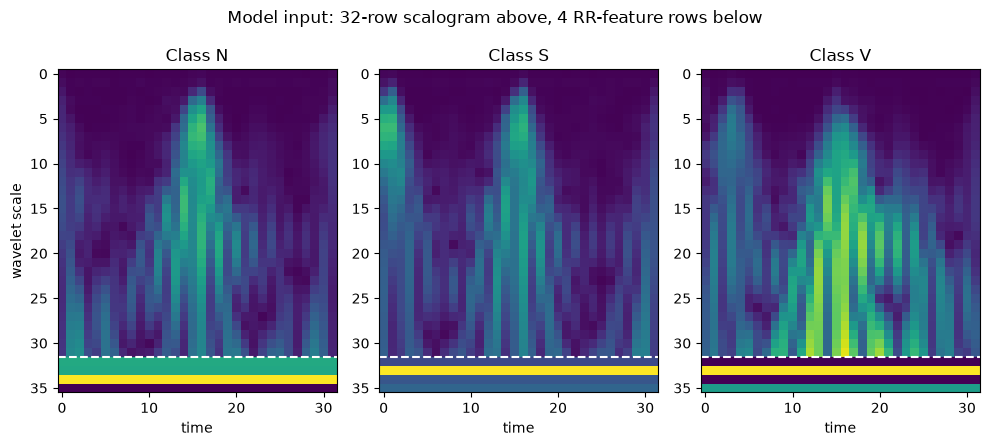

In [5]:
import matplotlib.pyplot as plt

# The test set is ordered by record and is not shuffled, so the opening batches
# are almost entirely normal beats — scan until an example of each class turns up
# rather than assuming the first batch holds all three.
examples = {}
for image_batch, label_batch in test_ds:
    images, labels = image_batch.numpy(), label_batch.numpy()
    for class_id in range(NUM_CLASSES):
        if class_id not in examples:
            idx = np.flatnonzero(labels == class_id)
            if len(idx) > 0:
                examples[class_id] = images[idx[0]]
    if len(examples) == NUM_CLASSES:
        break

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(10, 4.5))
for ax, class_id in zip(axes, range(NUM_CLASSES)):
    ax.imshow(examples[class_id].squeeze(), cmap='viridis', aspect='auto')
    # Scalogram rows sit above the line, the 4 RR-feature rows below it.
    ax.axhline(INPUT_SHAPE[0] - 4 - 0.5, color='w', linestyle='--', linewidth=1.5)
    ax.set_title(f'Class {TARGET_NAMES[class_id]}')
    ax.set_xlabel('time')
    ax.set_ylabel('wavelet scale' if class_id == 0 else '')

fig.suptitle('Model input: 32-row scalogram above, 4 RR-feature rows below')
fig.tight_layout()
plt.show()

## Model

A small depthwise-separable convolutional network — 23,363 parameters — where every
layer maps to Akida 1: a dense 16-filter stem convolution, three separable
convolution blocks of 32, 64 and 128 filters with stride-2 max pooling between them,
then global average pooling and two dense layers.

**Note: Input scaling is part of the model.** A `Rescaling` layer maps the uint8 inputs
the data pipeline produces into the [0, 1] range the network trains on. Keeping it
in the model graph means float training, quantized training and Akida inference all see
identical values — and `cnn2snn` folds the layer into the first convolution at
conversion time, so it costs nothing on hardware.

In [6]:
from arrhythmia_model import build_arrhythmia_model

model = build_arrhythmia_model(seed=SEED)
model.summary()

Model: "arrhythmia_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 36, 32, 1)]       0         
                                                                 
 rescaling (Rescaling)       (None, 36, 32, 1)         0         
                                                                 
 stem_conv (Conv2D)          (None, 36, 32, 16)        400       
                                                                 
 stem_bn (BatchNormalizatio  (None, 36, 32, 16)        64        
 n)                                                              
                                                                 
 stem_relu6 (ReLU)           (None, 36, 32, 16)        0         
                                                                 
 block1_sepconv (SeparableC  (None, 36, 32, 32)        912       
 onv2D)                                  

## Float Training

The model is trained in full float32 precision with the Adam optimiser and sparse
categorical cross-entropy (`from_logits=True` — the head outputs raw logits, with no
softmax).

**Class weighting is not optional here.** The training set is roughly 91% normal
beats, 2% supraventricular and 7% ventricular. Without reweighting, the model reaches
a perfectly respectable-looking accuracy by essentially ignoring the supraventricular
class — which is the class a cardiologist would most want flagged. `CLASS_WEIGHTS`
is `{N: 1.0, S: 6.0, V: 3.0}`: inverse-frequency-flavoured, tuned by hand to make the
minority classes count without destabilising training.

A small **activity regularization** term (`regularization=2e-7`, an L1L2 penalty
attached to every ReLU layer) pushes activations towards zero. On Akida, which skips
computation for zero-valued activations, that "sparsity" is latency and energy saved.

`epochs=80` is a ceiling rather than a duration. `ReduceLROnPlateau` cuts the learning
rate when validation loss stalls, `EarlyStopping` halts once it stops improving at
all, and `RestoreBest` puts the best weights back at the end.

Set `RUN_FLOAT_TRAINING = False` in the config cell to skip straight to the
pre-trained weights in `pretrained_models/`.

In [7]:
from arrhythmia_train import CLASS_WEIGHTS, train_arrhythmia

float_model_name = f'arrhythmia_classification{MODEL_SUFFIX}.h5'

if RUN_FLOAT_TRAINING:
    print(f'Class weights: {CLASS_WEIGHTS}')
    train_arrhythmia(model, train_ds, val_ds,
                     epochs=80,
                     learning_rate=3e-3,
                     regularization=2e-7,
                     class_weight=CLASS_WEIGHTS,
                     seed=SEED)
    model.save(MODELS_DIR + float_model_name, include_optimizer=False)
    print(f'Float model saved to {MODELS_DIR + float_model_name}')
else:
    print("Loading the pretrained model.")
    model = load_quantized_model('pretrained_models/' + float_model_name)

model.compile(metrics=['accuracy'])

Loading the pretrained model.


### Reading the results

Accuracy on its own flatters any model on this dataset. Around 90% of the test beats
are normal, so a model that predicted "normal" unconditionally would score 0.90 and
be entirely useless. The Macro F1 score (average of individual class F1) is more
meaningful.

The helper below prints accuracy alongside per-class precision, recall and F1, and
returns the accuracy and macro F1 for the summary table at the end. It is used
unchanged at all four stages of the pipeline — float, PTQ, QAT and Akida — so the
numbers are directly comparable.

In [8]:
def predict_keras(keras_model, dataset):
    """Run a tf_keras model over a dataset, returning (predictions, labels)."""
    logits = keras_model.predict(dataset, verbose=0)
    labels = np.concatenate([label_batch.numpy() for _, label_batch in dataset])
    return np.argmax(logits, axis=1), labels


def report(preds, labels, title):
    """Print accuracy and the per-class breakdown; return (accuracy, macro F1)."""
    accuracy = float(np.mean(preds == labels))
    scores = classification_report(labels, preds, target_names=list(TARGET_NAMES),
                                   output_dict=True, zero_division=0)
    macro_f1 = scores['macro avg']['f1-score']

    print(f'--- {title} ---')
    print(f'Accuracy: {accuracy:.4f}    Macro F1: {macro_f1:.4f}\n')
    print(classification_report(labels, preds, target_names=list(TARGET_NAMES),
                                digits=4, zero_division=0))
    return accuracy, macro_f1

In [9]:
float_acc, float_f1 = report(*predict_keras(model, test_ds), 'Float model')

I0000 00:00:1786964885.444372 2813480 cuda_dnn.cc:529] Loaded cuDNN version 90300


--- Float model ---
Accuracy: 0.9476    Macro F1: 0.7039

              precision    recall  f1-score   support

           N     0.9647    0.9844    0.9744     44224
           S     0.3879    0.2025    0.2661      1837
           V     0.8745    0.8677    0.8710      3219

    accuracy                         0.9476     49280
   macro avg     0.7424    0.6849    0.7039     49280
weighted avg     0.9373    0.9476    0.9413     49280



## Quantization

We apply Post-training quantization (PTQ) via `cnn2snn.quantize`:

- **Input**: 8-bit (`input_weight_quantization=8`)
- **Weights**: 4-bit (`weight_quantization=4`)
- **Activations**: 4-bit (`activ_quantization=4`)

4-bit weights and activations are what Akida 1 hardware requires. The first layer is
the exception — both its inputs and its weights can stay at 8-bit, which is worth
having, since that layer sees the raw scalogram.

Note the use of the `cnn2snn` package for quantization. That is the recommended route
for Akida 1 models, and contrasts with Akida 2 which must go via `quantizeml`.

In [10]:
quantized_model = cnn2snn.quantize(model,
                                    input_weight_quantization=8,
                                    weight_quantization=4,
                                    activ_quantization=4)
print('Model quantized to i8/w4/a4.')

Model quantized to i8/w4/a4.


Quantizing a model after training like this is Post-Training Quantization (PTQ). It
usually costs some accuracy — especially at 4 bits, as here — because the model was
trained with continuous weights but is now evaluated with discrete ones.

In [11]:
quantized_model.compile(metrics=['accuracy'])
ptq_acc, ptq_f1 = report(*predict_keras(quantized_model, test_ds), 'PTQ model')

--- PTQ model ---
Accuracy: 0.9337    Macro F1: 0.6409

              precision    recall  f1-score   support

           N     0.9650    0.9700    0.9675     44224
           S     0.4603    0.1198    0.1901      1837
           V     0.6656    0.8997    0.7651      3219

    accuracy                         0.9337     49280
   macro avg     0.6970    0.6631    0.6409     49280
weighted avg     0.9267    0.9337    0.9253     49280



## Quantization-Aware Training (QAT)

Quantization-Aware Training recovers most of that drop. Although it can sound
intimidating, QAT with BrainChip's tools is no more complex than sending the
quantized model back through the same training function that produced the float model
in the first place.

The learning rate stays at `3e-3` and the ceiling drops to 50 epochs; as before, the
plateau scheduler and early stopping usually finish sooner.

Set `RUN_QAT_TRAINING = False` in the config cell to load the pre-trained QAT model
instead.

**Note:** If you run with the pretrained weights, you'll see that after QAT, the model
achieves much better performance on the difficult S class. This is not a typical feature
of QAT: we generally hope to recover float performance, but not exceed it. Rather, this
is precisely the performance instability described in the introduction: chance level 
differences in training can flip the performance on that class.

In [12]:
qat_model_name = f'arrhythmia_classification{MODEL_SUFFIX}_qat.h5'

if RUN_QAT_TRAINING:
    if NAIVE_SPLIT:
        train_ds, val_ds, test_ds = get_naive_data(DATA_PATH, INPUT_SHAPE, BATCH_SIZE,
                                                seed=SEED)
    else:
        train_ds, val_ds = get_data(DATA_PATH, INPUT_SHAPE, BATCH_SIZE, seed=SEED)
        test_ds = get_test_data(DATA_PATH, INPUT_SHAPE, BATCH_SIZE)
    train_arrhythmia(quantized_model, train_ds, val_ds,
                     epochs=50,
                     learning_rate=3e-3,
                     regularization=2e-7,
                     class_weight=CLASS_WEIGHTS,
                     seed=SEED)
    quantized_model.save(MODELS_DIR + qat_model_name, include_optimizer=False)
    print(f'QAT model saved to {MODELS_DIR + qat_model_name}')
else:
    print("Loading the pretrained QAT model.")
    quantized_model = load_quantized_model('pretrained_models/' + qat_model_name)

quantized_model.compile(metrics=['accuracy'])

Loading the pretrained QAT model.


In [13]:
qat_acc, qat_f1 = report(*predict_keras(quantized_model, test_ds), 'QAT model')

--- QAT model ---
Accuracy: 0.9580    Macro F1: 0.8360

              precision    recall  f1-score   support

           N     0.9875    0.9687    0.9780     44224
           S     0.5823    0.7050    0.6378      1837
           V     0.8368    0.9556    0.8922      3219

    accuracy                         0.9580     49280
   macro avg     0.8022    0.8764    0.8360     49280
weighted avg     0.9626    0.9580    0.9597     49280



## Conversion to Akida Format

`cnn2snn.convert` compiles the quantized Keras model into an Akida `.fbz` model that
can be loaded and executed directly on AKD1500 hardware. The converter checks
hardware compatibility and maps each Keras layer to its Akida primitive — this is
also where the `Rescaling` layer gets folded into the stem convolution, and where
each convolution absorbs its batch normalisation.

In [14]:
with set_akida_version(AkidaVersion.v1):
    akida_model = cnn2snn.convert(quantized_model)

akida_model_path = os.path.join(
    MODELS_DIR, f'arrhythmia_classification{MODEL_SUFFIX}_qat.fbz')
akida_model.save(akida_model_path)
print(f'Akida model saved to {akida_model_path}\n')
akida_model.summary()

Akida model saved to ./models/arrhythmia_classification_qat.fbz

                Model Summary                 
______________________________________________
Input shape  Output shape  Sequences  Layers
[36, 32, 1]  [1, 1, 3]     1          6     
______________________________________________

___________________________________________________________
Layer (type)                Output shape  Kernel shape   

=========== SW/stem_conv-predictions (Software) ===========

stem_conv (InputConv.)      [36, 32, 16]  (5, 5, 1, 16)  
___________________________________________________________
block1_sepconv (Sep.Conv.)  [18, 16, 32]  (5, 5, 16, 1)  
___________________________________________________________
                                          (1, 1, 16, 32) 
___________________________________________________________
block2_sepconv (Sep.Conv.)  [9, 8, 64]    (5, 5, 32, 1)  
___________________________________________________________
                                          (1, 1, 32

## Evaluation of Akida Model

We now run the same evaluation through the Akida model, to confirm accuracy is
comparable to the quantized Keras model. Here we deliberately use the **software
backend** (the default, since we never look for or map to a connected device): it
delivers a bit-accurate simulation of what the hardware will produce.

In the accompanying
[arrhythmia_notebook_benchmark.ipynb](arrhythmia_notebook_benchmark.ipynb) the same
evaluation is run on the hardware backend, if a device is connected, so you can
confirm the results are identical.

### Run Evaluation on Akida

The Akida runtime cannot consume `tf.data.Dataset` objects directly — it expects a 4D
numpy array `(n, h, w, c)` in uint8 — so we iterate over the test batches manually.

One detail specific to this example: the dataset yields **float32 in the range
[0, 255]**, not uint8. The values are integral, so the cast back to `uint8` for the
Akida call is exact and lossless. It just has to be done.

The model output tensor has shape `(B, 1, 1, C)`, squeezed to `(B, C)` before taking
the class argmax.

In [15]:
labels_all = []
logits_all = []
for image_batch, label_batch in tqdm(test_ds, desc='Evaluating on Akida'):
    # Datasets here yield float32 in [0, 255]; Akida wants uint8. Values are
    # integral, so the cast is exact.
    logits_batch = akida_model.predict(image_batch.numpy().astype(np.uint8))
    logits_batch = logits_batch.squeeze(axis=(1, 2))  # (B, 1, 1, C) -> (B, C)

    labels_all.append(label_batch.numpy())
    logits_all.append(logits_batch)

labels_all = np.concatenate(labels_all)
preds = np.argmax(np.concatenate(logits_all), axis=1)

akida_acc, akida_f1 = report(preds, labels_all, 'Akida model (software backend)')

Evaluating on Akida: 100%|██████████| 770/770 [00:07<00:00, 96.93it/s]

--- Akida model (software backend) ---
Accuracy: 0.9577    Macro F1: 0.8355

              precision    recall  f1-score   support

           N     0.9875    0.9683    0.9778     44224
           S     0.5827    0.7055    0.6383      1837
           V     0.8330    0.9562    0.8904      3219

    accuracy                         0.9577     49280
   macro avg     0.8011    0.8767    0.8355     49280
weighted avg     0.9624    0.9577    0.9594     49280



### Activation Sparsity

Akida hardware skips computation for zero-valued activations, so activation sparsity
directly reduces both energy consumption and inference latency (although that will 
only be apparent in the hardware benchmarking). It is the payoff for
the activity regularization applied during training.

Note the important of using real inputs to measure sparsity. The sparsity inside the 
network is *learned*, and so can only be tested with relevant inputs.

In [16]:
from akida_models.sparsity import compute_sparsity
from brainchip_utils.plot_utils import pretty_print_sparsity

NUM_SPARSITY_SAMPLES = 1000

samples = get_samples(DATA_PATH, INPUT_SHAPE, num_samples=NUM_SPARSITY_SAMPLES,
                      seed=SEED)
sparsity_dict = compute_sparsity(akida_model, samples=samples)
pretty_print_sparsity(sparsity_dict)

sparsity = float(np.mean(list(sparsity_dict.values())))
print(f'\nMean activation sparsity over {NUM_SPARSITY_SAMPLES} beats: '
      f'{sparsity * 100:.2f}%')


Layer              Sparsity
---------------------------
stem_conv           68.55%
block1_sepconv      57.62%
block2_sepconv      80.69%
block3_sepconv      72.77%
dense               71.98%
predictions          0.00%
---------------------------
Mean                58.60%

Mean activation sparsity over 1000 beats: 58.60%


## Summary

The table below compares the three model variants. The goal is that QAT and Akida
accuracy stay close to the float baseline — and that the macro F1, which weights the
rare S and V classes equally with the abundant N class, holds up alongside it.

In [17]:
split_name = 'naive random' if NAIVE_SPLIT else 'inter-patient (DS1/DS2)'
print(f'Arrhythmia classification results — {split_name} split, seed {SEED}')
print('=' * 62)
print(f'{"":<16}{"Accuracy":>12}{"Macro F1":>12}')
print(f'  {"Float":<14}{float_acc * 100:>11.2f}%{float_f1:>12.3f}')
print(f'  {"PTQ":<14}{ptq_acc * 100:>11.2f}%{ptq_f1:>12.3f}')
print(f'  {"QAT":<14}{qat_acc * 100:>11.2f}%{qat_f1:>12.3f}')
print(f'  {"Akida":<14}{akida_acc * 100:>11.2f}%{akida_f1:>12.3f}')
print(f'\n  Mean activation sparsity: {sparsity * 100:.2f}%')
print(f'  Parameters:               {model.count_params():,}')

Arrhythmia classification results — inter-patient (DS1/DS2) split, seed 7
                    Accuracy    Macro F1
  Float               94.76%       0.704
  PTQ                 93.37%       0.641
  QAT                 95.80%       0.836
  Akida               95.77%       0.835

  Mean activation sparsity: 58.60%
  Parameters:               23,363


### A final word on what these numbers mean

On the default **inter-patient** split, and using the pretrained model, you should
find 95.8% accuracy with a macro F1 near 0.835. The S-class F1 is much the 
weakest of the three, somewhere around 0.64.

Now try setting `NAIVE_SPLIT = True` at the top and re-running. Accuracy jumps to
roughly 99% and S-class F1 to around 0.91 — same model, same code, same
hyperparameters. The only thing that changed is that test beats now come from the
same patients as the training beats, so the model has already learned those
individuals' rhythms. It is a genuinely easier question, and it is the question a
great deal of published MIT-BIH work quietly answers.

Neither figure is precise enough to settle an architecture question, either. About
87% of the S beats in the inter-patient test set come from just two patients, so that
score largely measures how well the model happens to fit one bradycardic patient's
idiosyncrasies. It moves a long way with the random seed — change `SEED` and watch.

The [Dataset limits](README.md#dataset-limits) section of the README works through
this in full. It is the most useful part of this example to read carefully.

**Next:** [arrhythmia_notebook_benchmark.ipynb](arrhythmia_notebook_benchmark.ipynb)
runs this converted model on an AKD1500 device and measures its latency and power.